# Pre-RA Flow PS1: Cell type level subclustering

## Setup

In [1]:
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce

print(sy.__version__)
print(anndata.__version__)


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


1.5.1
0.10.6


In [37]:
#### ==== parameter set up ==== ####
# define the working path
panel = "PS1"
# define cell types to subset
cell_types = ["total_t_cells", "total_myeloid_cells", "total_b_cells", "Other cells"]
data_path='/home/jupyter/projects/pre-ra/flow/raw-data/' + panel + '/labelled-expr/cache/'
fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + panel + '_celltype_subsample'  + "/"
proj_name = 'pre-ra_flow_clustering_' + panel
output_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/data/' +panel + '/'

if not os.path.exists(fig_path): os.makedirs(fig_path)
    
if not os.path.exists(output_path): os.makedirs(output_path)

# define scanpy verbose levels
sc.settings.verbosity = 3
sc.settings.figdir = fig_path
sc.settings.n_jobs = -1

## Functions

In [3]:
def subset_anndata_by_cell_types(anndata_obj, cell_types):
    """
    Subset Anndata object by specific cell types from the metadata column "labels".

    Parameters:
        anndata_obj (anndata.AnnData): Anndata object containing single-cell genomics data.
        cell_types (list): List of cell types to subset.

    Returns:
        dict: Dictionary containing cell types as keys and corresponding Anndata objects as values.
    """
    split_anndata = {}
    for cell_type in cell_types:
        subset_indices = anndata_obj.obs['l1_labels'] == cell_type
        subset_anndata = anndata_obj[subset_indices].copy()
        split_anndata[cell_type] = subset_anndata
    return split_anndata

In [51]:
def subsample_adata_by_group(anndata_obj, target_cells,cluster_key ):
    """
    Subsample Anndata object by specific groupings from the metadata columns by fix target cells.

    Parameters:
        anndata_obj (anndata.AnnData): Anndata object containing single-cell genomics data.
        cluster_key (list): List of cell groupings from metadata
        target_cells (num): an integer of the fixed targeted number of cells per groupings

    Returns:
        Anndata object
    """
    total_cells = len(anndata_obj)
    if total_cells < 5000000:  # Check if total cells is less than 5 million
        print("Total cells less than 5 million. No downsampling performed.")
        return anndata_obj  # Return the original Anndata object
    
    grouped = anndata_obj.obs.groupby(cluster_key)

    downsampled_indices = []
    for _, group in grouped:
        if len(group) > target_cells:
            downsampled_indices.extend(group.sample(target_cells).index)
        else:
            downsampled_indices.extend(group.index)
        
    adata_downsampled = adata_sub_celltype[downsampled_indices]
    return(adata_downsampled)

In [5]:
def save_anndata_list(anndata_list, filenames):
    """
    Save a list of Anndata objects to separate H5AD files.

    Parameters:
        anndata_list (list): List of Anndata objects to be saved.
        filenames (list): List of filenames to save Anndata objects.

    Returns:
        None
    """
    # zip() combines two lists into a single tuple
    for anndata_obj, filename in zip(adata_downsampled_celltypes, filenames):
        print(adata_downsampled_celltypes[anndata_obj])
        adata_downsampled_celltypes[anndata_obj].write_h5ad(filename)

In [6]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

## Read in data 

In [7]:
print("READING IN ADATA")
adata_file = output_path + "adata_preprocess_unscaled_" + panel + ".h5ad"
print(adata_file)
adata = sc.read_h5ad(adata_file)
print(adata)

READING IN ADATA
/home/jupyter/projects/pre-ra/flow/02-clustering/data/PS1/adata_preprocess_unscaled_PS1.h5ad
AnnData object with n_obs × n_vars = 50861579 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels'


In [8]:
cell_labels_to_subset_list = adata.obs['l1_labels'].unique()
print(cell_labels_to_subset_list)

['total_nk_cells', 'total_t_cells', 'total_myeloid_cells', 'total_b_cells', 'unknown', 'debris', 'Other cells']
Categories (7, object): ['Other cells', 'debris', 'total_b_cells', 'total_myeloid_cells', 'total_nk_cells', 'total_t_cells', 'unknown']


In [9]:
print(pd.crosstab(adata.obs['sample_id'], adata.obs['l1_labels'], margins=True)) 


l1_labels   Other cells  debris  total_b_cells  total_myeloid_cells  \
sample_id                                                             
PB00052-02          334     210           9760                12761   
PB00055-02          857     609          32272                27807   
PB00056-02         1630     984          46200               101170   
PB00057-02          365     546          21169                31743   
PB00058-03          248     194          10596                59204   
...                 ...     ...            ...                  ...   
PB04671-00          416     318          23443                50078   
PB04906-00          382     606          36201                24610   
PB04933-00          330     273          28522                32865   
PB04937-00          205     616          22893                22449   
All               86903   77587        3257608              7640695   

l1_labels   total_nk_cells  total_t_cells  unknown       All  
sample_id    

In [10]:
print(pd.crosstab(adata.obs['l1_labels'], adata.obs['panel'], margins=True)) 


panel                     PS1       All
l1_labels                              
Other cells             86903     86903
debris                  77587     77587
total_b_cells         3257608   3257608
total_myeloid_cells   7640695   7640695
total_nk_cells        4595700   4595700
total_t_cells        30101085  30101085
unknown               5102001   5102001
All                  50861579  50861579


In [11]:
### read in metadata 
meta = pd.read_csv("/home/jupyter/projects/pre-ra/flow/raw-data/2023-11-22_ALTRA_Metadata_labs_long-model-vars.csv")

In [12]:
meta["sample.sampleKitGuid"]

0      KT00052
1      KT00055
2      KT00056
3      KT00057
4      KT00058
        ...   
152    KT04924
153    KT04933
154    KT04937
155    KT02968
156    KT04906
Name: sample.sampleKitGuid, Length: 157, dtype: object

In [13]:
meta = meta[[ 'sample.sampleKitGuid','Status_Xsec','Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv','bmi_conv','Age2023']]

In [14]:
meta.head()

,sample.sampleKitGuid,Status_Xsec,Status_Long,subject.biologicalSex,subject.subjectGuid,days_to_conversion,age_conv,bmi_conv,Age2023
0,KT00052,at_risk,pre,Female,CU1009,-714.0,58.0,25.648918,60
1,KT00055,early_RA,NaN,Female,CU1008,NaN,NaN,NaN,57
2,KT00056,at_risk,pre,Female,CU1007,-632.0,44.0,26.194977,46
3,KT00057,at_risk,pre,Female,CU1003,-615.0,23.0,23.143062,25
4,KT00058,at_risk,NaN,Female,CU1002,NaN,NaN,NaN,82


In [15]:
### add sample.sampleKitGuid to column metadata of anndata before merging metadata
sample_id = adata.obs["sample_id"]

sliced_ids = [ids[2:7] for ids in sample_id]
sampleKitGuid = ["KT" + ids for ids in sliced_ids]

In [16]:
adata.obs["sample.sampleKitGuid"] = sampleKitGuid

In [17]:
adata.obs[["sample.sampleKitGuid", "sample_id"]].head()

,sample.sampleKitGuid,sample_id
0-0,KT02817,PB02817-00
1-0,KT02817,PB02817-00
2-0,KT02817,PB02817-00
3-0,KT02817,PB02817-00
4-0,KT02817,PB02817-00


In [18]:
### merge meta info back to adata obj
adata.obs = pd.merge(adata.obs, meta, on='sample.sampleKitGuid', how='inner')


In [19]:
adata.obs.head()

,Unnamed: 0,sample_id,cell_id,barcode,Time,SSC-W,SSC-H,SSC-A,FSC-W,FSC-H,...,sample.sampleKitGuid,l1_labels,Status_Xsec,Status_Long,subject.biologicalSex,subject.subjectGuid,days_to_conversion,age_conv,bmi_conv,Age2023
0,0,PB02817-00,1,a1c54a441f6511eda7a03a93708f33ca,0.0,698343.3750,548845.0,638803.8125,753859.3125,884942.0,...,KT02817,total_nk_cells,NaN,pre,Female,CU1010,-401.0,62.0,24.550265,62
1,1,PB02817-00,2,a1c54a761f6511eda7a03a93708f33ca,4.0,707237.1250,757549.0,892944.6875,747715.6250,638566.0,...,KT02817,total_nk_cells,NaN,pre,Female,CU1010,-401.0,62.0,24.550265,62
2,2,PB02817-00,4,a1c54ac61f6511eda7a03a93708f33ca,10.0,675248.1250,354607.0,399079.5000,702365.0625,865534.0,...,KT02817,total_t_cells,NaN,pre,Female,CU1010,-401.0,62.0,24.550265,62
3,3,PB02817-00,5,a1c54ae41f6511eda7a03a93708f33ca,13.0,689138.1250,504520.0,579473.2500,729230.3750,549946.0,...,KT02817,total_t_cells,NaN,pre,Female,CU1010,-401.0,62.0,24.550265,62
4,4,PB02817-00,7,a1c54b341f6511eda7a03a93708f33ca,18.0,697988.8125,599090.0,696930.1875,759985.5000,721084.0,...,KT02817,total_nk_cells,NaN,pre,Female,CU1010,-401.0,62.0,24.550265,62


In [20]:
adata.obs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50861579 entries, 0 to 50861578
Data columns (total 28 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Unnamed: 0             int64   
 1   sample_id              category
 2   cell_id                int64   
 3   barcode                object  
 4   Time                   float64 
 5   SSC-W                  float64 
 6   SSC-H                  float64 
 7   SSC-A                  float64 
 8   FSC-W                  float64 
 9   FSC-H                  float64 
 10  FSC-A                  float64 
 11  SSC-B-W                float64 
 12  SSC-B-H                float64 
 13  SSC-B-A                float64 
 14  Viability_logicle      float64 
 15  labels                 category
 16  batch                  category
 17  panel                  category
 18  sample.sampleKitGuid   object  
 19  l1_labels              category
 20  Status_Xsec            object  
 21  Status_Long            object

## Subset by sample selection 

In [21]:
meta[meta['days_to_conversion'] <= -750]

,sample.sampleKitGuid,Status_Xsec,Status_Long,subject.biologicalSex,subject.subjectGuid,days_to_conversion,age_conv,bmi_conv,Age2023
7,KT00064,at_risk,pre,Female,CU1010,-1144.0,62.0,24.550265,62
16,KT00075,at_risk,pre,Male,CU1021,-1037.0,68.0,25.660730,69
27,KT00093,NaN,pre,Male,CU1021,-848.0,68.0,25.660730,69
29,KT00097,NaN,pre,Female,CU1010,-1035.0,62.0,24.550265,62
48,KT00424,NaN,pre,Male,CU1021,-778.0,68.0,25.660730,69
51,KT00443,at_risk,pre,Female,CU1033,-818.0,49.0,31.161374,49


In [22]:
len(meta['sample.sampleKitGuid'].unique())

157

In [23]:
len(adata.obs['sample.sampleKitGuid'].unique())

140

In [24]:
samples_to_remove = meta[meta['days_to_conversion'] <= -750]["sample.sampleKitGuid"]

In [25]:
len(samples_to_remove)

6

In [26]:
# Convert the column to string type if it's not already
adata.obs['sample.sampleKitGuid'] = adata.obs['sample.sampleKitGuid'].astype(str)

In [27]:
# Define the condition based on the metadata in the "obs" slot
condition = ~adata.obs['sample.sampleKitGuid'].isin(samples_to_remove)


In [28]:
# Use boolean indexing with the negation operator (~) to remove samples that meet the condition
adata_sub = adata[condition]

In [29]:
# check if samples to remove is still in filtered adata
adata_sub.obs['sample.sampleKitGuid'].isin(samples_to_remove).any()

False

In [30]:
len(adata_sub.obs['sample.sampleKitGuid'].unique())

134

In [31]:
adata_sub.write_h5ad(output_path + "adata_preprocess_unscaled_sample_select_sub_" + panel + ".h5ad")

In [32]:
adata_sub

AnnData object with n_obs × n_vars = 48816249 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [33]:
print(pd.crosstab(adata_sub.obs['l1_labels'], adata_sub.obs['panel'], margins=True)) 


panel                     PS1       All
l1_labels                              
Other cells             83215     83215
debris                  75121     75121
total_b_cells         3138083   3138083
total_myeloid_cells   7215601   7215601
total_nk_cells        4380660   4380660
total_t_cells        29011354  29011354
unknown               4912215   4912215
All                  48816249  48816249


In [34]:
cellcount_sampleselect = pd.crosstab(adata_sub.obs['sample_id'], adata_sub.obs['l1_labels'], margins=True)

cellcount_sampleselect.reset_index().rename_axis(None, axis=1)

cellcount_sampleselect = cellcount_sampleselect.add_prefix("sample_select_")

In [35]:
cellcount_sampleselect

l1_labels,sample_select_Other cells,sample_select_debris,sample_select_total_b_cells,sample_select_total_myeloid_cells,sample_select_total_nk_cells,sample_select_total_t_cells,sample_select_unknown,sample_select_All
sample_id,,,,,,,,
PB00052-02,334,210,9760,12761,28192,118413,29592,199262
PB00055-02,857,609,32272,27807,14660,235286,29279,340770
PB00056-02,1630,984,46200,101170,69270,443344,58600,721198
PB00057-02,365,546,21169,31743,19689,175322,20403,269237
PB00058-03,248,194,10596,59204,16284,122207,31280,240013
...,...,...,...,...,...,...,...,...
PB04671-00,416,318,23443,50078,23417,183063,24138,304873
PB04906-00,382,606,36201,24610,33999,196874,24236,316908
PB04933-00,330,273,28522,32865,8926,139318,20286,230520


## Subset Cell Types 

### Sample composition in cell types

In [39]:
adata_sub_celltype = adata_sub[adata_sub.obs['l1_labels'].isin(cell_types)]

In [46]:
adata_sub_celltype

View of AnnData object with n_obs × n_vars = 39448253 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [40]:
meta_adata_type_sub = adata_sub.obs[adata_sub.obs['l1_labels'].isin(cell_types)]

In [41]:
pd.crosstab(meta_adata_type_sub['sample_id'], meta_adata_type_sub['l1_labels'], margins=True)


l1_labels,Other cells,total_b_cells,total_myeloid_cells,total_t_cells,All
sample_id,,,,,
PB00052-02,334,9760,12761,118413,141268
PB00055-02,857,32272,27807,235286,296222
PB00056-02,1630,46200,101170,443344,592344
PB00057-02,365,21169,31743,175322,228599
PB00058-03,248,10596,59204,122207,192255
...,...,...,...,...,...
PB04671-00,416,23443,50078,183063,257000
PB04906-00,382,36201,24610,196874,258067
PB04933-00,330,28522,32865,139318,201035


In [42]:
celltype_counts = pd.crosstab(meta_adata_type_sub['sample_id'], meta_adata_type_sub['l1_labels'], margins=True)

celltype_counts.reset_index().rename_axis(None, axis=1)

,sample_id,Other cells,total_b_cells,total_myeloid_cells,total_t_cells,All
0,PB00052-02,334,9760,12761,118413,141268
1,PB00055-02,857,32272,27807,235286,296222
2,PB00056-02,1630,46200,101170,443344,592344
3,PB00057-02,365,21169,31743,175322,228599
4,PB00058-03,248,10596,59204,122207,192255
...,...,...,...,...,...,...
130,PB04671-00,416,23443,50078,183063,257000
131,PB04906-00,382,36201,24610,196874,258067
132,PB04933-00,330,28522,32865,139318,201035
133,PB04937-00,205,22893,22449,215878,261425


In [43]:
celltype_counts.describe()

l1_labels,Other cells,total_b_cells,total_myeloid_cells,total_t_cells,All
count,135.000000,1.350000e+02,1.350000e+02,1.350000e+02,1.350000e+02
mean,1232.814815,4.649012e+04,1.068978e+05,4.297978e+05,5.844186e+05
std,7117.897538,2.682727e+05,6.172007e+05,2.479517e+06,3.371381e+06
min,112.000000,3.348000e+03,2.619000e+03,8.586800e+04,1.077070e+05
25%,364.500000,1.554750e+04,2.819600e+04,1.761970e+05,2.367495e+05
50%,546.000000,2.344300e+04,4.903100e+04,2.024800e+05,2.728400e+05
75%,803.500000,3.018400e+04,7.473050e+04,2.354540e+05,3.238175e+05
max,83215.000000,3.138083e+06,7.215601e+06,2.901135e+07,3.944825e+07


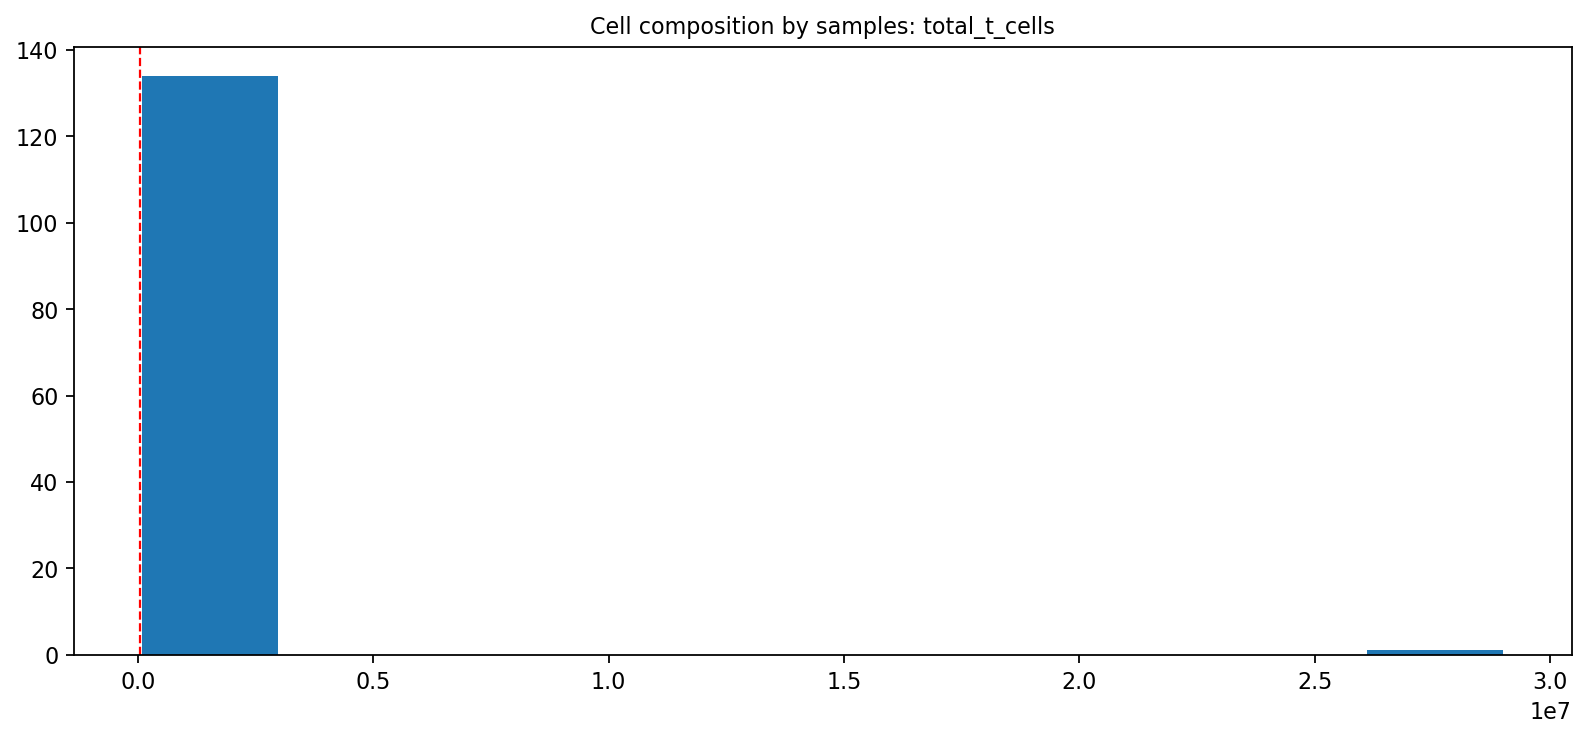

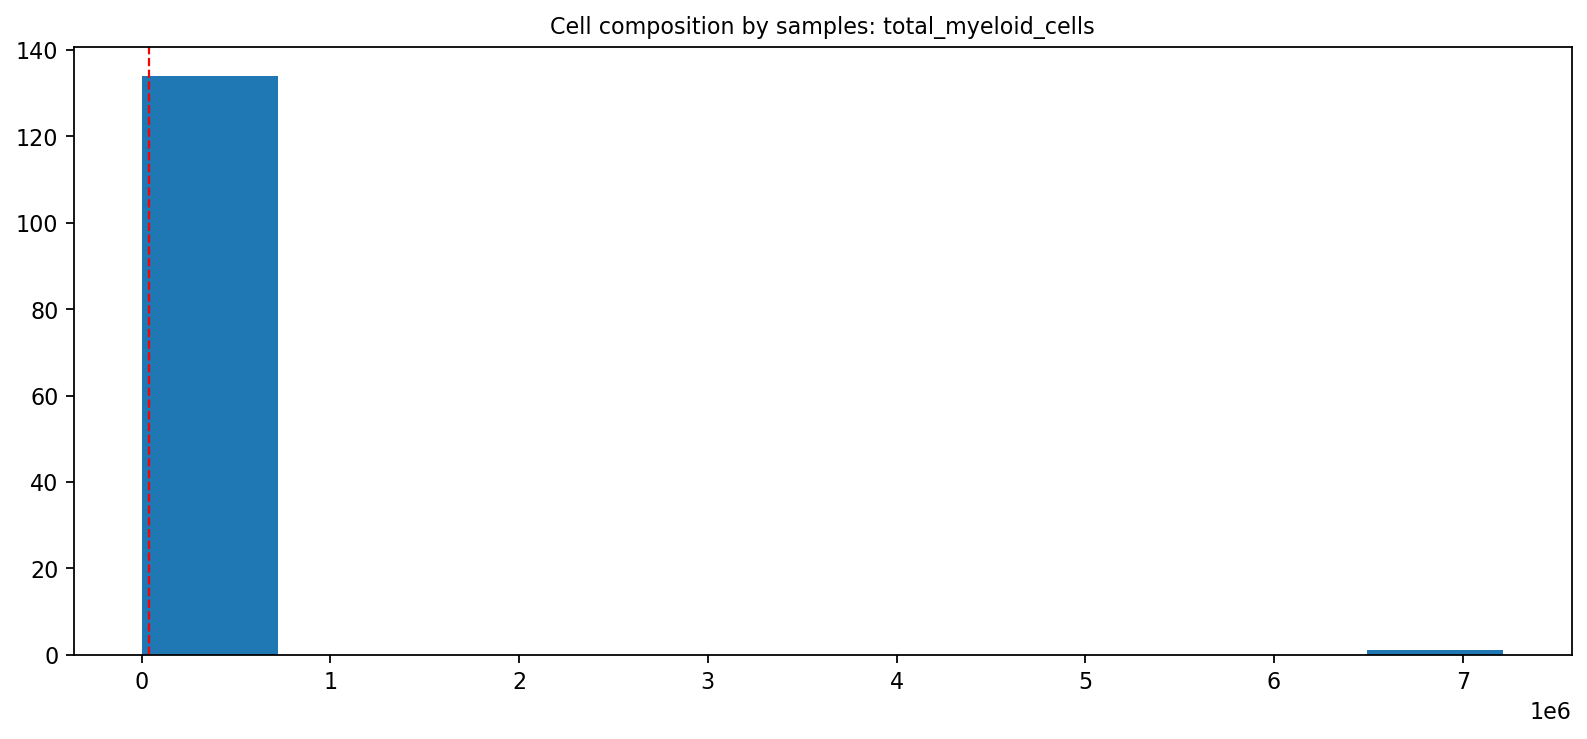

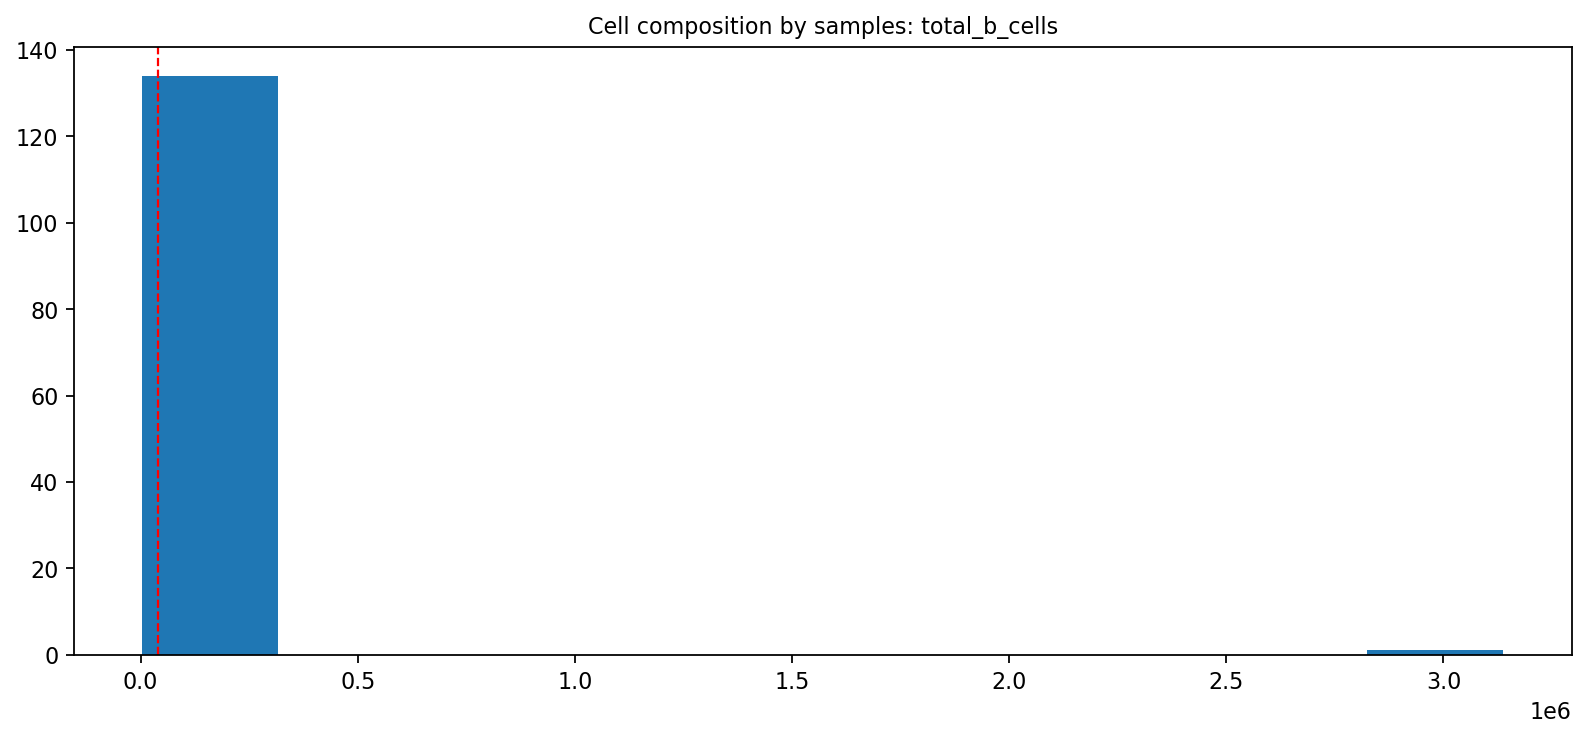

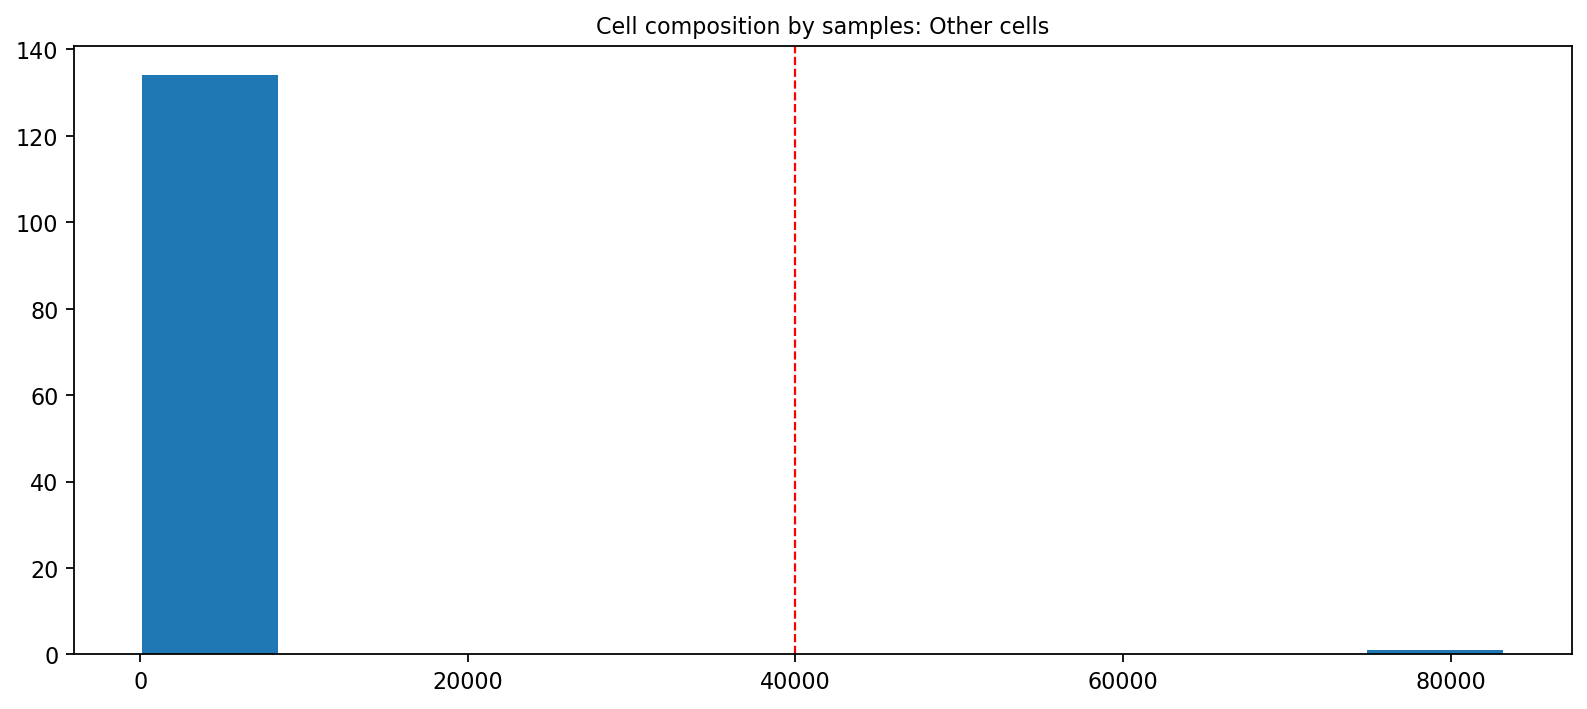

In [44]:
for ct in cell_types:
    plt.figure(figsize=(12, 5))
    plt.title("Cell composition by samples: " + ct)
    plt.hist(celltype_counts[[ct]])
    plt.axvline(40000, color='red', linestyle='dashed', linewidth=1)

### Conditional cell type subsets

In [53]:
adata_downsampled = subsample_adata_by_group(adata_sub_celltype, target_cells = 40000,cluster_key= ["sample_id", "l1_labels"] )

/tmp/ipykernel_41471/937687182.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = anndata_obj.obs.groupby(cluster_key)


In [54]:
adata_downsampled

View of AnnData object with n_obs × n_vars = 13037491 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'

In [55]:
celltype_counts_downsample =pd.crosstab(adata_downsampled.obs['sample_id'], adata_downsampled.obs["l1_labels"],margins=True)

In [56]:
celltype_counts_downsample.reset_index().rename_axis(None, axis=1)

,sample_id,Other cells,total_b_cells,total_myeloid_cells,total_t_cells,All
0,PB00052-02,334,9760,12761,40000,62855
1,PB00055-02,857,32272,27807,40000,100936
2,PB00056-02,1630,40000,40000,40000,121630
3,PB00057-02,365,21169,31743,40000,93277
4,PB00058-03,248,10596,40000,40000,90844
...,...,...,...,...,...,...
130,PB04671-00,416,23443,40000,40000,103859
131,PB04906-00,382,36201,24610,40000,101193
132,PB04933-00,330,28522,32865,40000,101717
133,PB04937-00,205,22893,22449,40000,85547


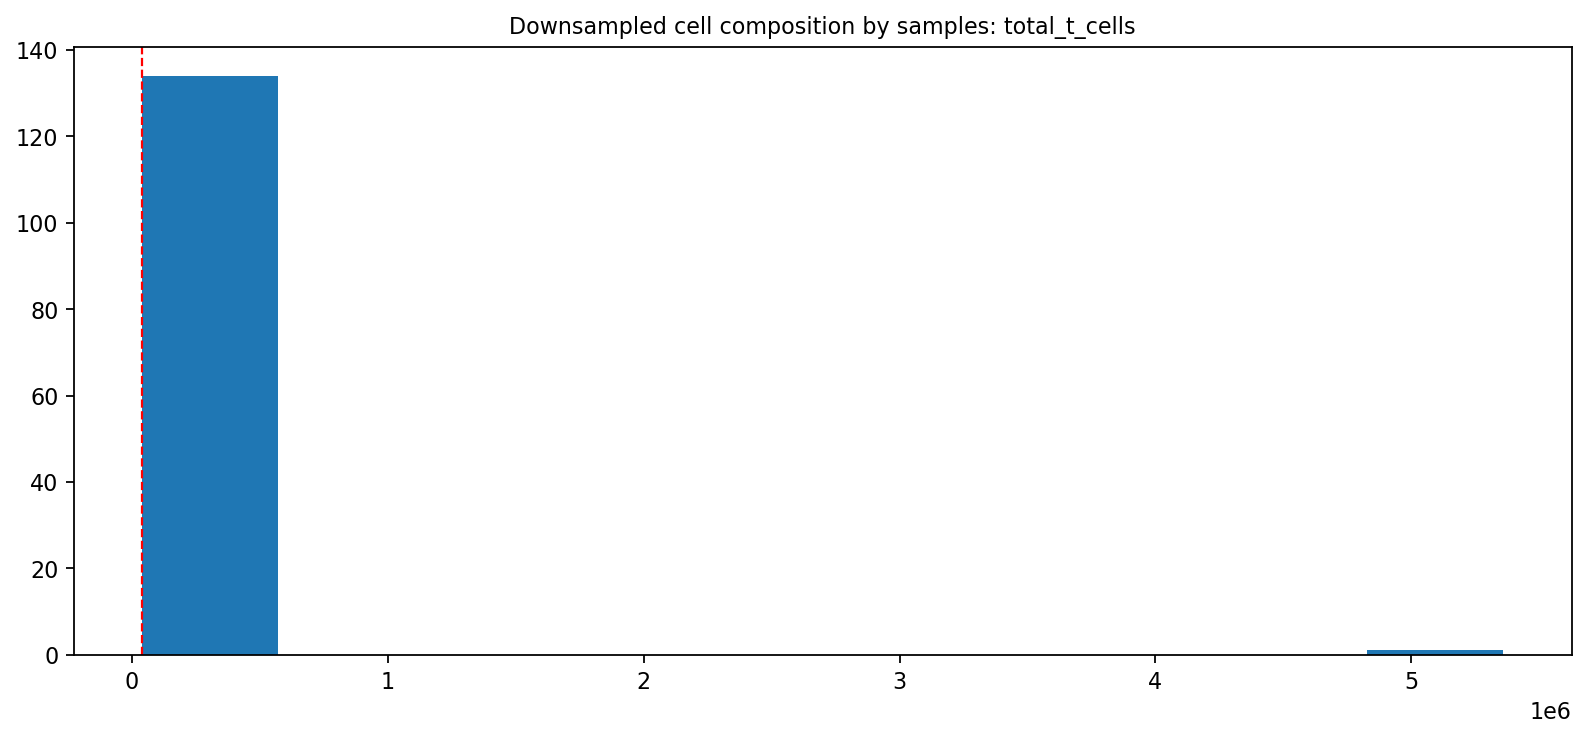

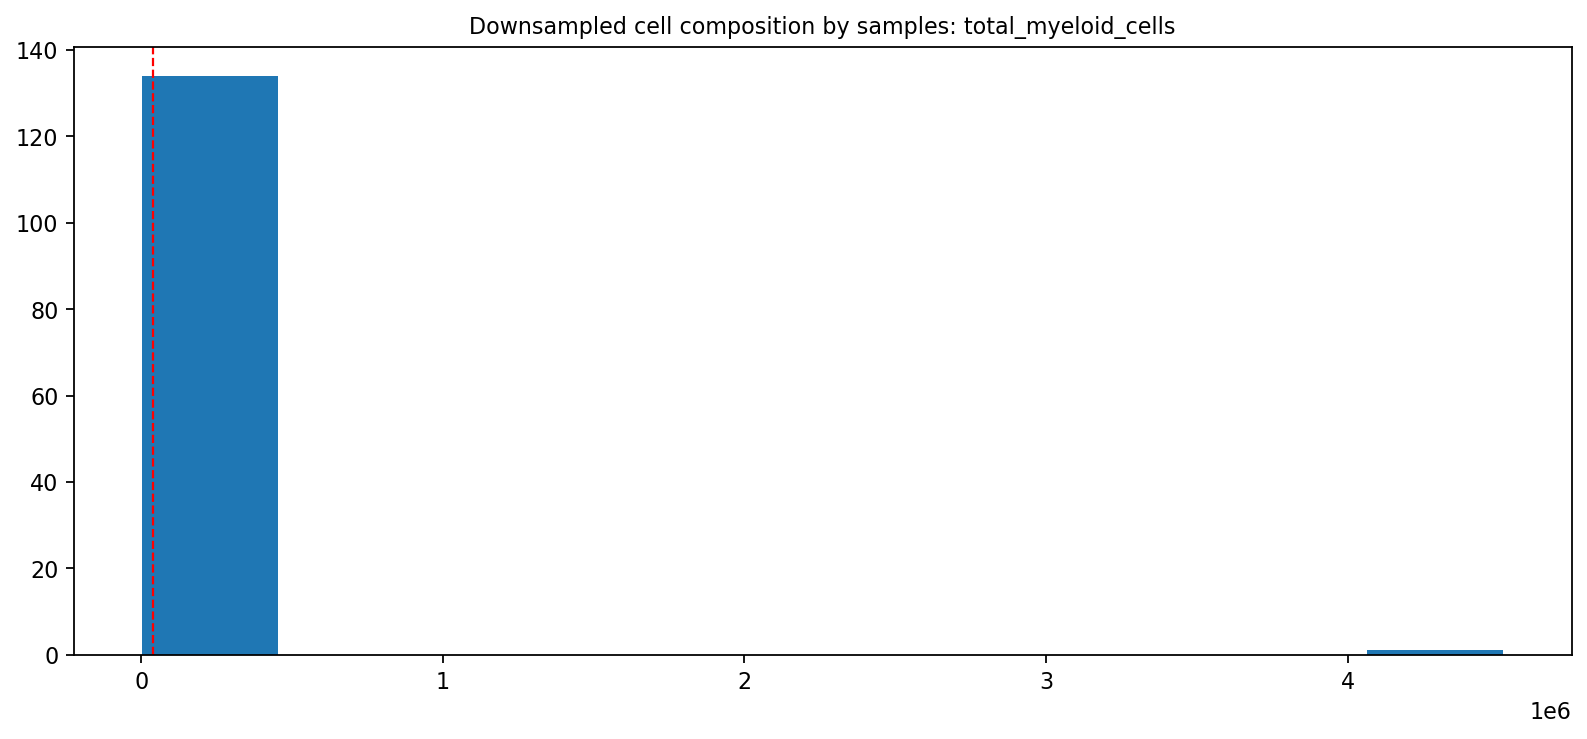

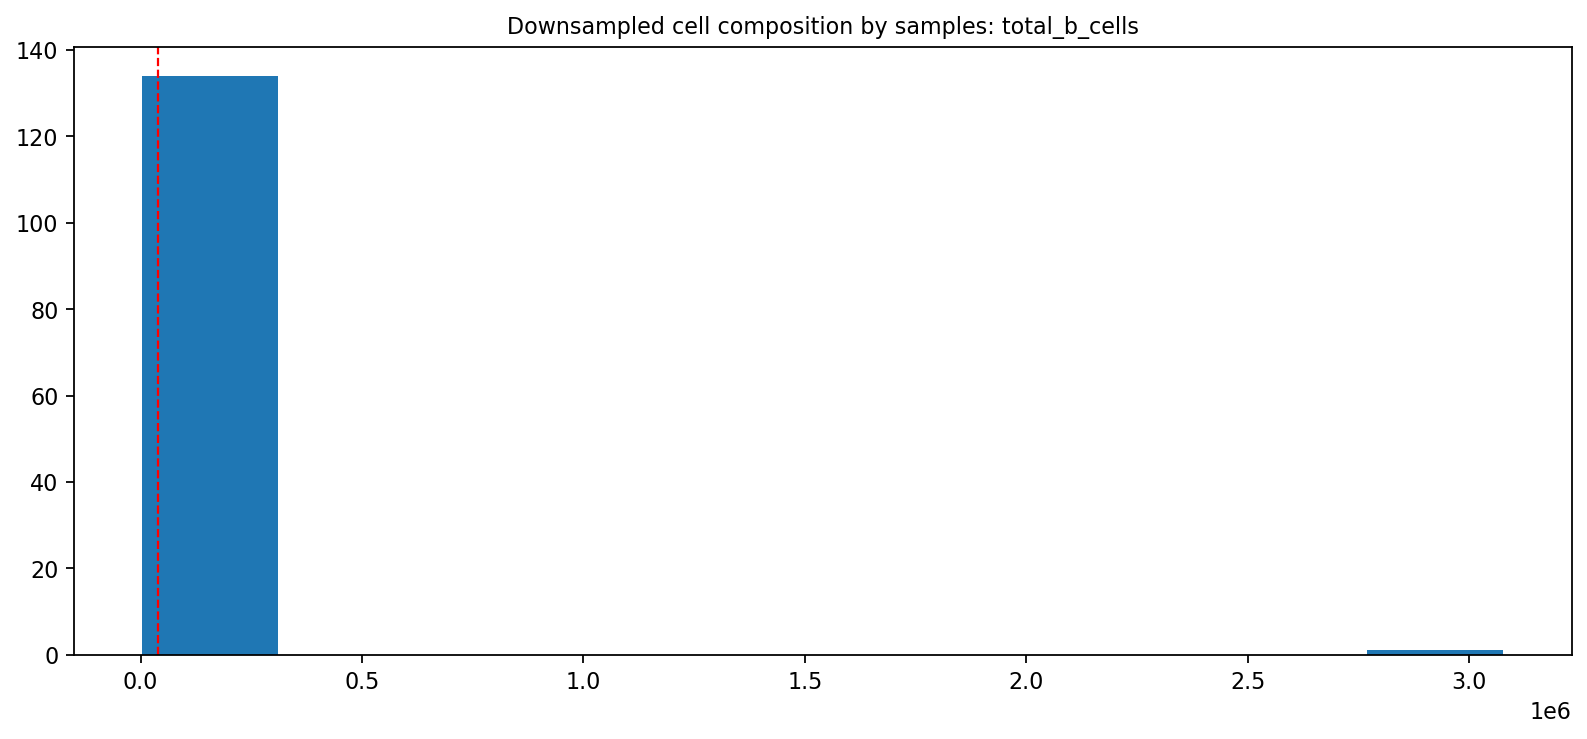

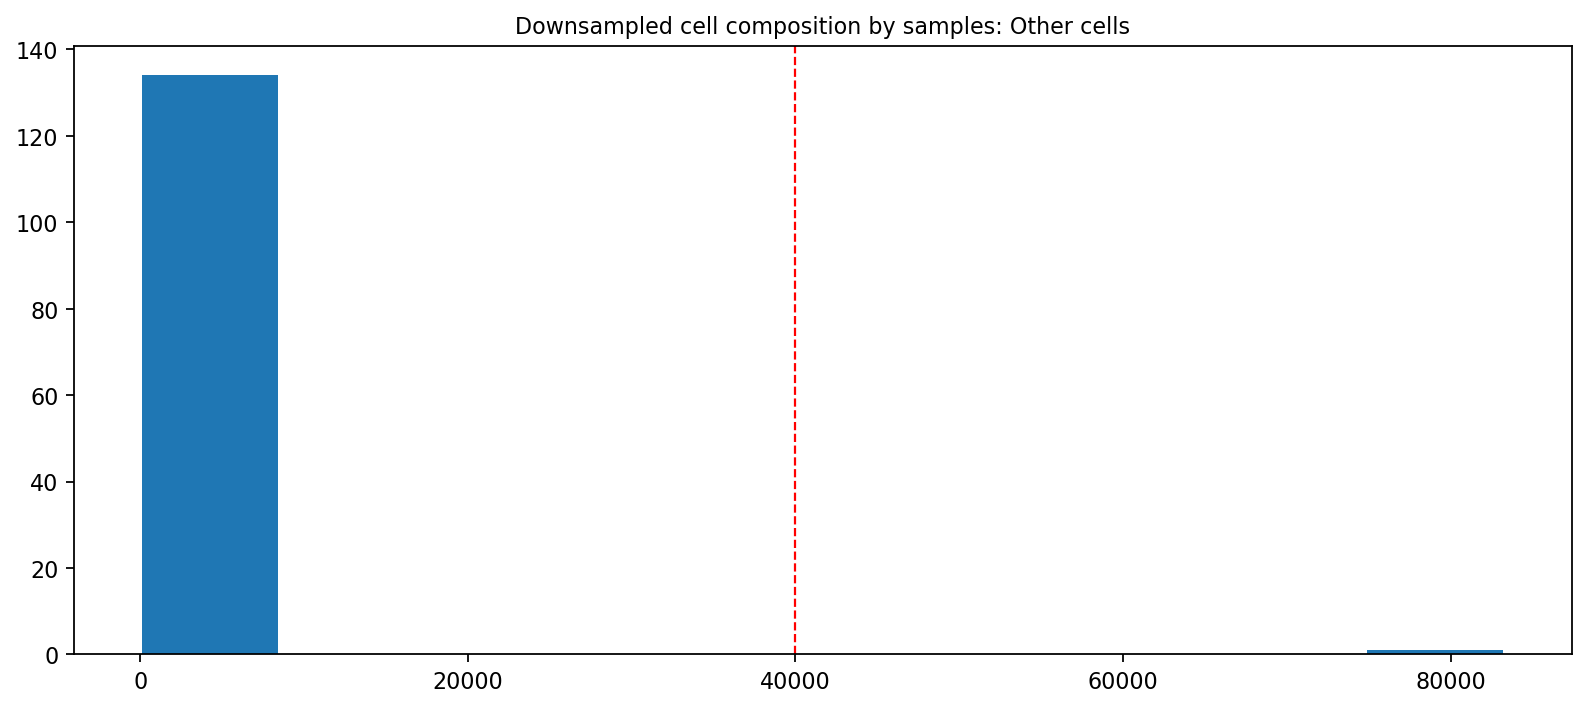

In [57]:
for ct in cell_types:
    plt.figure(figsize=(12, 5))
    plt.title("Downsampled cell composition by samples: " + ct)
    plt.hist(celltype_counts_downsample[[ct]])
    plt.axvline(40000, color='red', linestyle='dashed', linewidth=1)

In [58]:
celltype_counts_downsample = celltype_counts_downsample.add_prefix("downsample_")

In [59]:
adata_downsampled_celltypes = subset_anndata_by_cell_types(adata_downsampled,cell_types)

In [60]:
adata_downsampled_celltypes

{'total_t_cells': AnnData object with n_obs × n_vars = 5360000 × 24
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023',
 'total_myeloid_cells': AnnData object with n_obs × n_vars = 4516415 × 24
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023',
 'total_b_cells': AnnData object with n_obs × n_vars = 3077861 × 24
     obs: 'Unnamed: 0', 'sample_id', 'ce

In [61]:
filenames = [output_path + "adata_preprocess_unscaled_downsmpl_celltypes_" + cell_type + "_" + panel + ".h5ad" for cell_type in cell_types]

In [63]:
save_anndata_list(adata_downsampled_celltypes, filenames)

AnnData object with n_obs × n_vars = 5360000 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
AnnData object with n_obs × n_vars = 4516415 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
AnnData object with n_obs × n_vars = 3077861 × 24
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'F

In [64]:
file_tups = list(zip(filenames, cell_types))
file_tups

[('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PS1/adata_preprocess_unscaled_downsmpl_celltypes_total_t_cells_PS1.h5ad',
  'total_t_cells'),
 ('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PS1/adata_preprocess_unscaled_downsmpl_celltypes_total_myeloid_cells_PS1.h5ad',
  'total_myeloid_cells'),
 ('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PS1/adata_preprocess_unscaled_downsmpl_celltypes_total_b_cells_PS1.h5ad',
  'total_b_cells'),
 ('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PS1/adata_preprocess_unscaled_downsmpl_celltypes_Other cells_PS1.h5ad',
  'Other cells')]

In [65]:
### check anndata after exporting

adata_downsampled_celltypes = read_anndata_files(file_tups)
adata_downsampled_celltypes

{'total_t_cells': AnnData object with n_obs × n_vars = 5360000 × 24
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023',
 'total_myeloid_cells': AnnData object with n_obs × n_vars = 4516415 × 24
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'sample.sampleKitGuid', 'l1_labels', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023',
 'total_b_cells': AnnData object with n_obs × n_vars = 3077861 × 24
     obs: 'Unnamed: 0', 'sample_id', 'ce

## Cell Frequency Tables

In [66]:
cellcount_sampleselect.reset_index(inplace=True)

In [67]:
celltype_counts_downsample.reset_index(inplace=True)

In [68]:
### merge total counts (after sample selection) to 
cellcounts_df = pd.merge(cellcount_sampleselect, celltype_counts_downsample)

In [69]:
cellcounts_df

l1_labels,sample_id,sample_select_Other cells,sample_select_debris,sample_select_total_b_cells,sample_select_total_myeloid_cells,sample_select_total_nk_cells,sample_select_total_t_cells,sample_select_unknown,sample_select_All,downsample_Other cells,downsample_total_b_cells,downsample_total_myeloid_cells,downsample_total_t_cells,downsample_All
0,PB00052-02,334,210,9760,12761,28192,118413,29592,199262,334,9760,12761,40000,62855
1,PB00055-02,857,609,32272,27807,14660,235286,29279,340770,857,32272,27807,40000,100936
2,PB00056-02,1630,984,46200,101170,69270,443344,58600,721198,1630,40000,40000,40000,121630
3,PB00057-02,365,546,21169,31743,19689,175322,20403,269237,365,21169,31743,40000,93277
4,PB00058-03,248,194,10596,59204,16284,122207,31280,240013,248,10596,40000,40000,90844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,PB04671-00,416,318,23443,50078,23417,183063,24138,304873,416,23443,40000,40000,103859
131,PB04906-00,382,606,36201,24610,33999,196874,24236,316908,382,36201,24610,40000,101193
132,PB04933-00,330,273,28522,32865,8926,139318,20286,230520,330,28522,32865,40000,101717
133,PB04937-00,205,616,22893,22449,60985,215878,24771,347797,205,22893,22449,40000,85547


In [70]:
cellcounts_df.to_csv(output_path + "counts_freq_celltypes_sample_select_" + panel + ".csv")